# Лабораторная работа №3 — вариант 15

In [ ]:
# %pip install -q opencv-python-headless matplotlib numpy pandas scipy scikit-image

In [ ]:
import zipfile

zip_path = "lab3.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(".")

print(f"Архив {zip_path} распакован в текущую директорию.")

In [2]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.ndimage import gaussian_laplace, uniform_filter
from skimage import color, exposure, feature, io, transform, util

LAB_ROOT = Path(__file__).parent if "__file__" in globals() else Path().resolve()
DATA_DIR = LAB_ROOT / "lab3"
IMAGE_PATH = DATA_DIR / "image_v-15.jpg"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})


In [3]:
def load_image(path: Path) -> np.ndarray:
    image = io.imread(path)
    if image.ndim == 2:
        image = color.gray2rgb(image)
    if image.dtype != np.uint8:
        image = util.img_as_ubyte(image)
    return image


def to_gray(image: np.ndarray) -> np.ndarray:
    if image.dtype != np.float32:
        img_float = image.astype(np.float32) / 255.0
    else:
        img_float = image
    if img_float.ndim == 2:
        return img_float
    return color.rgb2gray(img_float).astype(np.float32)


def describe_image(image: np.ndarray) -> Dict[str, float]:
    h, w = image.shape[:2]
    channels = image.shape[2] if image.ndim == 3 else 1
    bit_depth = image.dtype.itemsize * 8
    stats = {
        "height": h,
        "width": w,
        "channels": channels,
        "bit_depth": bit_depth,
        "min_value": float(image.min()),
        "max_value": float(image.max()),
        "mean_value": float(image.mean()),
        "std_value": float(image.std()),
    }
    return stats


def show_fig(fig: Figure, caption: str | None = None) -> None:
    if caption:
        display(Markdown(f"**{caption}**"))
    display(fig)
    plt.close(fig)


def plot_image_pair(color_img: np.ndarray, gray_img: np.ndarray) -> Figure:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(color_img)
    axes[0].set_title("Исходное изображение")
    axes[0].axis("off")
    axes[1].imshow(gray_img, cmap="gray")
    axes[1].set_title("Изображение в градациях серого")
    axes[1].axis("off")
    fig.suptitle("Визуализация исходных данных", fontsize=14)
    return fig


In [4]:
def moravec_response(gray: np.ndarray, window: int) -> np.ndarray:
    assert window % 2 == 1, "Window size should be odd"
    shifts = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1, 1),
        (1, -1),
        (-1, 1),
        (-1, -1),
    ]
    responses = []
    for dy, dx in shifts:
        shifted = np.roll(np.roll(gray, dy, axis=0), dx, axis=1)
        diff = (gray - shifted) ** 2
        responses.append(uniform_filter(diff, size=window))
    stacked = np.stack(responses, axis=0)
    return stacked.min(axis=0)


def peak_coords(response: np.ndarray, min_distance: int, threshold_rel: float) -> np.ndarray:
    threshold_abs = threshold_rel * np.max(response)
    coords = feature.peak_local_max(
        response,
        min_distance=min_distance,
        threshold_abs=threshold_abs,
        exclude_border=False,
    )
    return coords


def render_points(ax, base_img: np.ndarray, coords: np.ndarray, title: str) -> None:
    ax.imshow(base_img)
    if len(coords):
        ax.scatter(coords[:, 1], coords[:, 0], s=15, c="lime", linewidths=0.4)
    ax.set_title(title)
    ax.axis("off")


In [5]:
def moravec_section(gray: np.ndarray, color_img: np.ndarray) -> Tuple[pd.DataFrame, Figure]:
    configs = [
        {"window": 5, "min_distance": 4, "threshold_rel": 0.20},
        {"window": 9, "min_distance": 6, "threshold_rel": 0.15},
        {"window": 13, "min_distance": 8, "threshold_rel": 0.12},
    ]
    rows = len(configs)
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)
    records = []
    for idx, cfg in enumerate(configs):
        response = moravec_response(gray, cfg["window"])
        coords = peak_coords(
            response,
            min_distance=cfg["min_distance"],
            threshold_rel=cfg["threshold_rel"],
        )
        ax_resp, ax_pts = axes[idx]
        ax_resp.imshow(response, cmap="magma")
        ax_resp.set_title(f"Показатель Моравеца (окно {cfg['window']}×{cfg['window']})")
        ax_resp.axis("off")
        render_points(ax_pts, color_img, coords, f"Ключевые точки (N={len(coords)})")
        records.append(
            {
                "window": cfg["window"],
                "threshold_rel": cfg["threshold_rel"],
                "min_distance": cfg["min_distance"],
                "num_points": int(len(coords)),
            }
        )
    fig.suptitle("Детектор Моравеца: карта отклика и точки", fontsize=14)
    return pd.DataFrame(records), fig


def harris_section(gray: np.ndarray, color_img: np.ndarray) -> Tuple[pd.DataFrame, Figure]:
    gray_8 = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    gray_f = np.float32(gray_8)
    block_size, ksize, k = 5, 3, 0.05

    responses = {
        "Харрис": cv2.cornerHarris(gray_f, blockSize=block_size, ksize=ksize, k=k),
    }
    eigen = cv2.cornerEigenValsAndVecs(gray_f, blockSize=block_size, ksize=ksize)
    lambda1, lambda2 = eigen[..., 0], eigen[..., 1]
    trace, det = lambda1 + lambda2, lambda1 * lambda2
    eps = 1e-9
    responses["Нобле"] = det / (trace + eps)
    responses["Ши–Томаси"] = np.minimum(lambda1, lambda2)

    params = {
        "Харрис": {"threshold_rel": 0.10, "min_distance": 6},
        "Нобле": {"threshold_rel": 0.08, "min_distance": 6},
        "Ши–Томаси": {"threshold_rel": 0.05, "min_distance": 6},
    }

    rows = len(responses)
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)
    records = []
    for idx, (name, resp) in enumerate(responses.items()):
        coords = peak_coords(resp, params[name]["min_distance"], params[name]["threshold_rel"])
        ax_resp, ax_pts = axes[idx]
        ax_resp.imshow(resp, cmap="viridis")
        ax_resp.set_title(f"Показатель {name}")
        ax_resp.axis("off")
        render_points(ax_pts, color_img, coords, f"Ключевые точки (N={len(coords)})")
        records.append(
            {
                "detector": name,
                "num_points": int(len(coords)),
                "threshold_rel": params[name]["threshold_rel"],
                "min_distance": params[name]["min_distance"],
                "block_size": block_size,
                "ksize": ksize,
                "k": k if name == "Харрис" else None,
            }
        )
    fig.suptitle("Детекторы Харриса / Нобле / Ши–Томаси", fontsize=14)
    return pd.DataFrame(records), fig


def log_section(gray: np.ndarray) -> Tuple[pd.DataFrame, Dict[str, Figure]]:
    sigma_values = [1.0, 2.0, 3.5, 5.0, 7.5, 10.0]
    log_maps = []
    fig_grid, axes = plt.subplots(2, 3, figsize=(14, 8))
    records = []
    for idx, sigma in enumerate(sigma_values):
        response = gaussian_laplace(gray, sigma=sigma)
        log_maps.append(response)
        r, c = divmod(idx, 3)
        ax = axes[r, c]
        im = ax.imshow(response, cmap="seismic")
        ax.set_title(f"LoG σ={sigma}")
        ax.axis("off")
        fig_grid.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    fig_grid.suptitle("LoG-фильтр для разных σ", fontsize=14)

    sample_pixels = [(150, 150), (250, 350), (400, 200), (500, 500), (100, 450), (300, 100)]
    fig_curves, ax_curves = plt.subplots(figsize=(7, 4))
    stacked = np.stack(log_maps, axis=0)
    for (y, x) in sample_pixels:
        curve = [log_map[y, x] for log_map in log_maps]
        ax_curves.plot(sigma_values, curve, marker="o", label=f"({x}, {y})")
    ax_curves.set_xlabel("σ")
    ax_curves.set_ylabel("LoG отклик")
    ax_curves.set_title("Зависимость отклика от σ для выбранных пикселей")
    ax_curves.legend(fontsize=8)

    norm_stack = np.abs(stacked) * (np.array(sigma_values)[:, None, None] ** 2)
    sigma_idx = np.argmax(norm_stack, axis=0)
    sigma_map = np.take(np.array(sigma_values), sigma_idx)
    sigma_strength = np.max(norm_stack, axis=0)
    strength_threshold = np.percentile(sigma_strength, 99) * 0.5
    mask = sigma_strength > strength_threshold

    fig_scale, ax_scale = plt.subplots(figsize=(6, 6))
    ax_scale.imshow(gray, cmap="gray")
    sc = ax_scale.scatter(
        np.where(mask)[1],
        np.where(mask)[0],
        c=sigma_map[mask],
        s=8,
        cmap="viridis",
    )
    ax_scale.set_title("Карта характеристических размеров")
    ax_scale.axis("off")
    fig_scale.colorbar(sc, ax=ax_scale, fraction=0.046, pad=0.04, label="σ*")

    keypoints = []
    for idx, sigma in enumerate(sigma_values):
        score = norm_stack[idx]
        coords = feature.peak_local_max(
            score,
            min_distance=max(2, int(round(sigma * 1.5))),
            threshold_rel=0.3,
        )
        for (y, x) in coords:
            keypoints.append((y, x, sigma))

    fig_kp, ax_kp = plt.subplots(figsize=(6, 6))
    ax_kp.imshow(gray, cmap="gray")
    for (y, x, sigma) in keypoints:
        radius = np.sqrt(2) * sigma
        circle = Circle((x, y), radius, edgecolor="lime", linewidth=0.6, fill=False, alpha=0.8)
        ax_kp.add_patch(circle)
    ax_kp.set_title("LoG-детектор с окружностями масштаба")
    ax_kp.axis("off")

    summary = pd.DataFrame(
        {
            "sigma": sigma_values,
            "max_abs_response": [float(np.max(np.abs(log_map))) for log_map in log_maps],
        }
    )
    figs = {
        "grid": fig_grid,
        "curves": fig_curves,
        "scale": fig_scale,
        "keypoints": fig_kp,
    }
    return summary, figs


def sift_section(gray: np.ndarray) -> Tuple[pd.DataFrame, Figure]:
    gray_norm = (gray - gray.min()) / (gray.max() - gray.min() + 1e-6)
    configs = [
        {"octaves": 3, "scales": 3},
        {"octaves": 4, "scales": 3},
        {"octaves": 4, "scales": 5},
        {"octaves": 5, "scales": 5},
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    records = []
    for idx, cfg in enumerate(configs):
        sift = feature.SIFT(n_octaves=cfg["octaves"], n_scales=cfg["scales"])
        sift.detect_and_extract(gray_norm)
        keypoints = sift.keypoints
        scales = sift.scales if len(sift.scales) else np.array([])
        row, col = divmod(idx, 2)
        ax = axes[row, col]
        ax.imshow(gray, cmap="gray")
        if len(keypoints):
            scatter = ax.scatter(keypoints[:, 1], keypoints[:, 0], s=5, c=scales, cmap="plasma")
            fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.02, label="scale")
        ax.set_title(f"SIFT: {cfg['octaves']} октав, {cfg['scales']} масштабов")
        ax.axis("off")
        records.append(
            {
                "octaves": cfg["octaves"],
                "scales": cfg["scales"],
                "num_keypoints": int(len(keypoints)),
                "avg_scale": float(scales.mean()) if len(scales) else 0.0,
            }
        )
    fig.suptitle("SIFT-детектор при разных настройках пирамиды", fontsize=14)
    return pd.DataFrame(records), fig


def transform_image(image: np.ndarray, transform_name: str) -> np.ndarray:
    img_float = image.astype(np.float32)
    if transform_name == "original":
        return image
    if transform_name == "rot30":
        rotated = transform.rotate(image, angle=30, resize=False, preserve_range=True, mode="edge")
        return rotated.astype(np.uint8)
    if transform_name == "gamma07":
        norm = img_float / 255.0
        gamma_adj = exposure.adjust_gamma(norm, gamma=0.7, gain=1.0)
        return np.clip(gamma_adj * 255.0, 0, 255).astype(np.uint8)
    if transform_name == "downscale2":
        scaled = transform.rescale(image, scale=0.5, channel_axis=-1, anti_aliasing=True, preserve_range=True)
        return np.clip(scaled, 0, 255).astype(np.uint8)
    raise ValueError(f"Unknown transform {transform_name}")


def invariance_section(
    base_image: np.ndarray,
    moravec_cfg: Dict,
    harris_cfg: Dict,
    log_cfg: Dict,
    sift_cfg: Dict,
) -> Tuple[pd.DataFrame, Dict[str, Figure]]:
    transforms = ["original", "rot30", "gamma07", "downscale2"]
    counts = []
    figs = {}
    for detector in ["moravec", "harris", "log", "sift"]:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        for idx, name in enumerate(transforms):
            ax = axes[idx // 2, idx % 2]
            img_t = transform_image(base_image, name)
            gray_t = to_gray(img_t)
            if detector == "moravec":
                response = moravec_response(gray_t, moravec_cfg["window"])
                coords = peak_coords(response, moravec_cfg["min_distance"], moravec_cfg["threshold_rel"])
                render_points(ax, img_t, coords, f"{name}: N={len(coords)}")
                counts.append({"transform": name, "detector": detector, "num_keypoints": len(coords)})
            elif detector == "harris":
                gray_8 = cv2.normalize(gray_t, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
                resp = cv2.cornerHarris(
                    np.float32(gray_8),
                    blockSize=harris_cfg["block_size"],
                    ksize=harris_cfg["ksize"],
                    k=harris_cfg["k"],
                )
                coords = peak_coords(resp, harris_cfg["min_distance"], harris_cfg["threshold_rel"])
                render_points(ax, img_t, coords, f"{name}: N={len(coords)}")
                counts.append({"transform": name, "detector": detector, "num_keypoints": len(coords)})
            elif detector == "log":
                log_resp = gaussian_laplace(gray_t, sigma=log_cfg["sigma"])
                score = np.abs(log_resp) * (log_cfg["sigma"] ** 2)
                coords = feature.peak_local_max(
                    score,
                    min_distance=log_cfg["min_distance"],
                    threshold_rel=log_cfg["threshold_rel"],
                )
                render_points(ax, img_t, coords, f"{name}: N={len(coords)}")
                counts.append({"transform": name, "detector": detector, "num_keypoints": len(coords)})
            else:  # SIFT
                sift = feature.SIFT(n_octaves=sift_cfg["octaves"], n_scales=sift_cfg["scales"])
                gray_norm = (gray_t - gray_t.min()) / (gray_t.max() - gray_t.min() + 1e-6)
                sift.detect_and_extract(gray_norm)
                kp = sift.keypoints
                ax.imshow(img_t)
                if len(kp):
                    ax.scatter(kp[:, 1], kp[:, 0], s=5, c="cyan")
                ax.set_title(f"{name}: N={len(kp)}")
                ax.axis("off")
                counts.append({"transform": name, "detector": detector, "num_keypoints": len(kp)})
        fig.suptitle(f"Инвариантность: детектор {detector.upper()}", fontsize=14)
        figs[detector] = fig
    counts_df = pd.DataFrame(counts)
    return counts_df, figs


/Users/23108022/Documents/repositories/mephi-computer-vision-2025/.venv/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Users/23108022/Documents/repositories/mephi-computer-vision-2025/.venv/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Users/23108022/Documents/repositories/mephi-computer-vision-2025/.venv/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


### 1. Исходные данные

,height,width,channels,bit_depth,min_value,max_value,mean_value,std_value
0,1280,1920,3,8,0.0,255.0,124.07982,77.683252


**Исходное изображение и его серый канал**

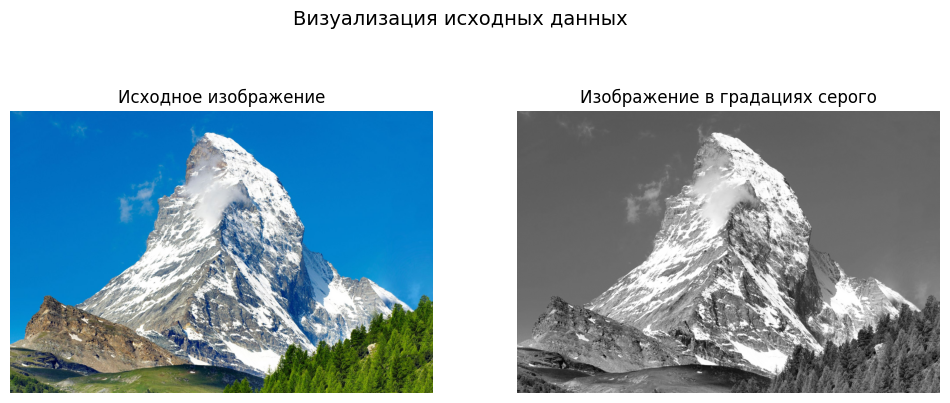

In [6]:
image = load_image(IMAGE_PATH)
gray = to_gray(image)

image_stats = describe_image(image)
display(Markdown("### 1. Исходные данные"))
display(pd.DataFrame([image_stats]))
show_fig(plot_image_pair(image, gray), caption="Исходное изображение и его серый канал")


### 2. Детекторы Моравеца и Харриса

#### 2а. Моравец

,window,threshold_rel,min_distance,num_points
0,5,0.20,4,1601
1,9,0.15,6,1245
2,13,0.12,8,1044


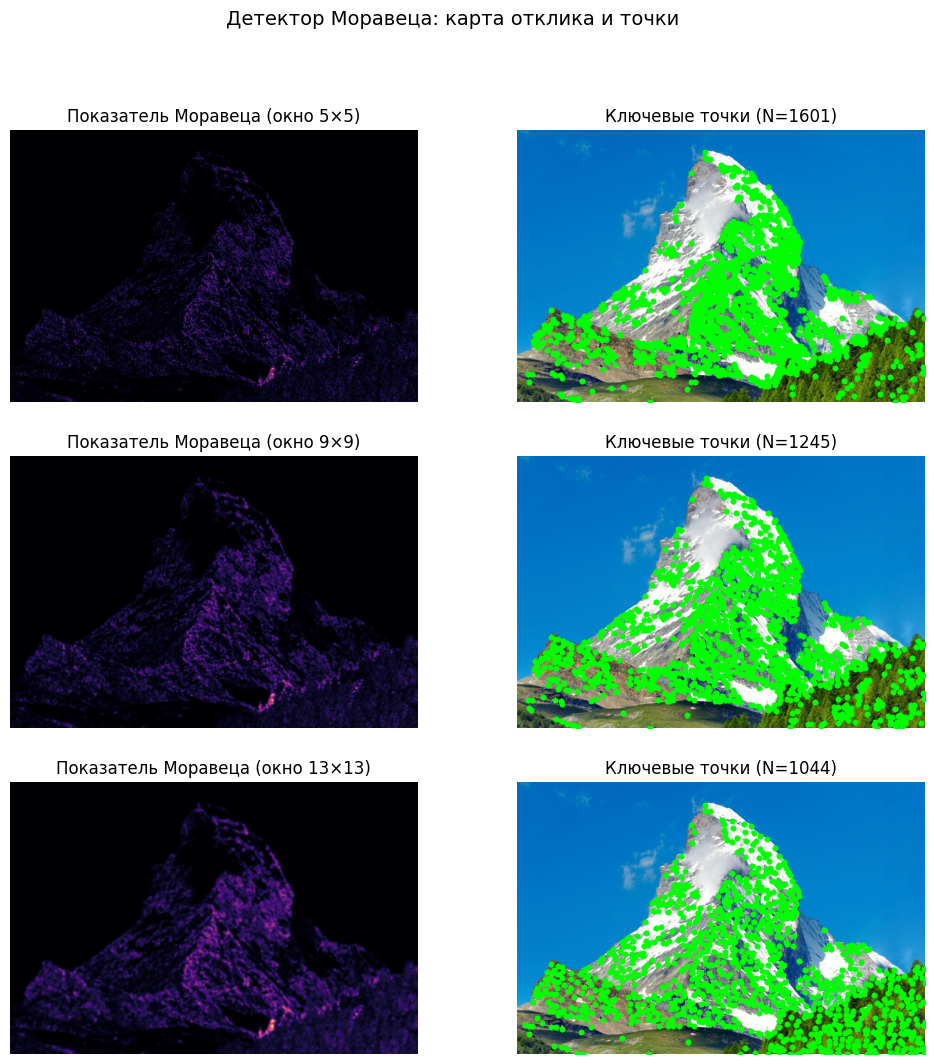

#### 2б. Харрис / Нобле / Ши–Томаси

,detector,num_points,threshold_rel,min_distance,block_size,ksize,k
0,Харрис,696,0.10,6,5,3,0.05
1,Нобле,3198,0.08,6,5,3,NaN
2,Ши–Томаси,3620,0.05,6,5,3,NaN


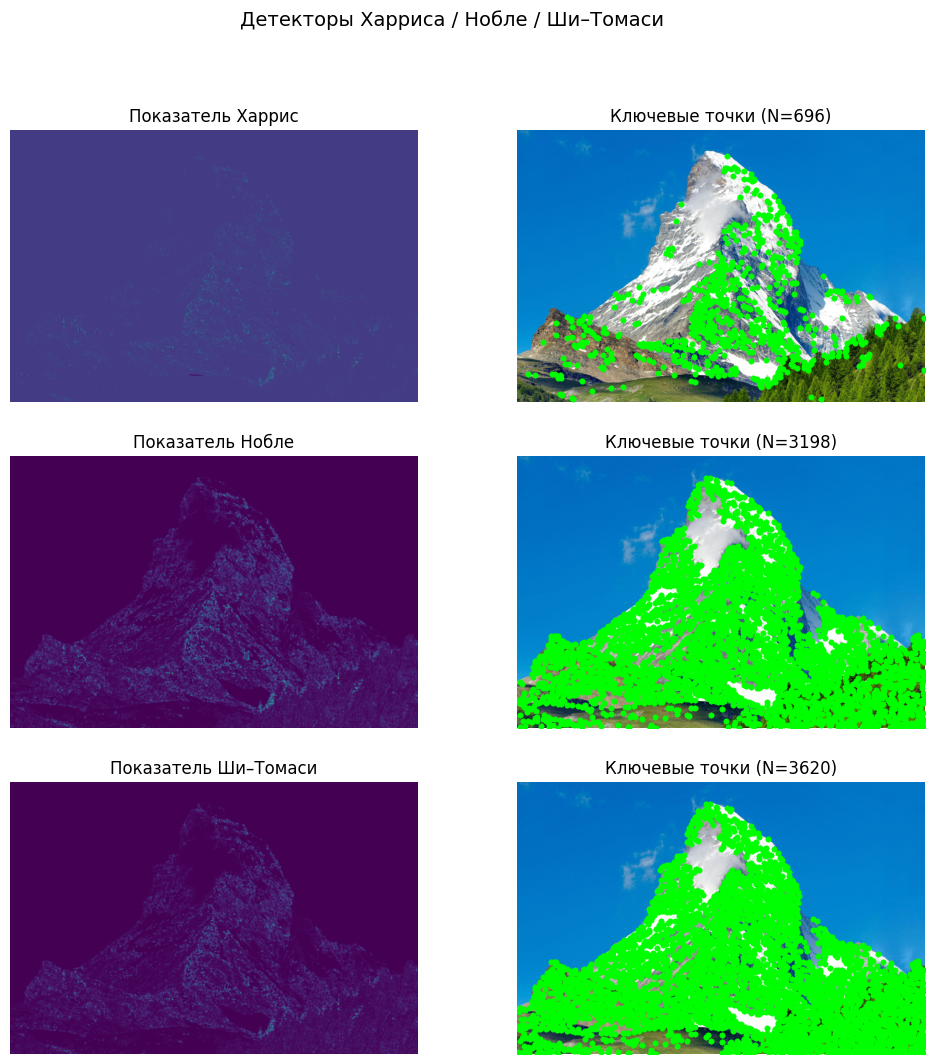

In [7]:
display(Markdown("### 2. Детекторы Моравеца и Харриса"))

moravec_df, moravec_fig = moravec_section(gray, image)
display(Markdown("#### 2а. Моравец"))
display(moravec_df)
show_fig(moravec_fig)

harris_df, harris_fig = harris_section(gray, image)
display(Markdown("#### 2б. Харрис / Нобле / Ши–Томаси"))
display(harris_df)
show_fig(harris_fig)


### 3. LoG-детектор

,sigma,max_abs_response
0,1.0,0.386848
1,2.0,0.093427
2,3.5,0.031209
3,5.0,0.013609
4,7.5,0.005804
5,10.0,0.003276


**LoG-фильтр для различных σ**

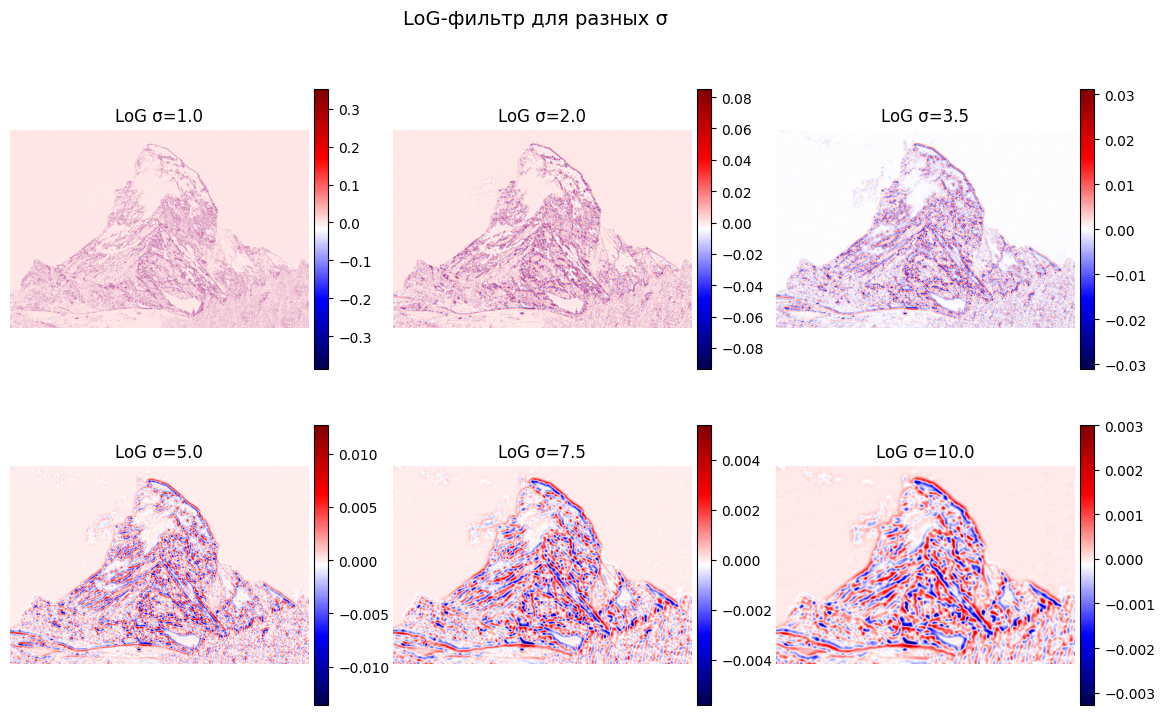

**Отклик отдельных пикселей в зависимости от σ**

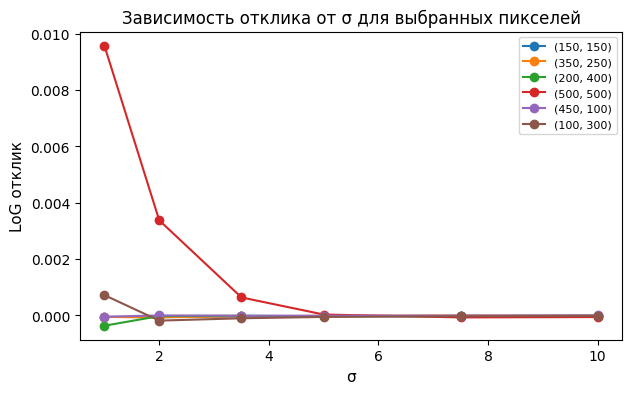

**Карта характеристических размеров**

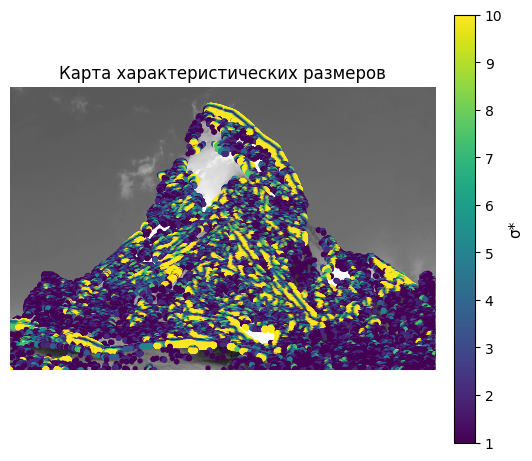

**LoG-детектор с радиусами масштабов**

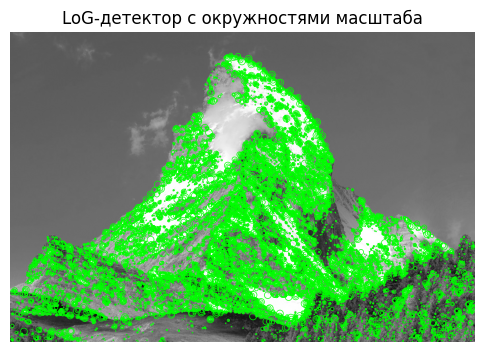

In [8]:
display(Markdown("### 3. LoG-детектор"))
log_summary, log_figs = log_section(gray)
display(log_summary)
show_fig(log_figs["grid"], caption="LoG-фильтр для различных σ")
show_fig(log_figs["curves"], caption="Отклик отдельных пикселей в зависимости от σ")
show_fig(log_figs["scale"], caption="Карта характеристических размеров")
show_fig(log_figs["keypoints"], caption="LoG-детектор с радиусами масштабов")


### 4. SIFT-детектор

,octaves,scales,num_keypoints,avg_scale
0,3,3,23241,1.666882
1,4,3,23507,1.667546
2,4,5,32632,2.336480
3,5,5,32738,2.336948


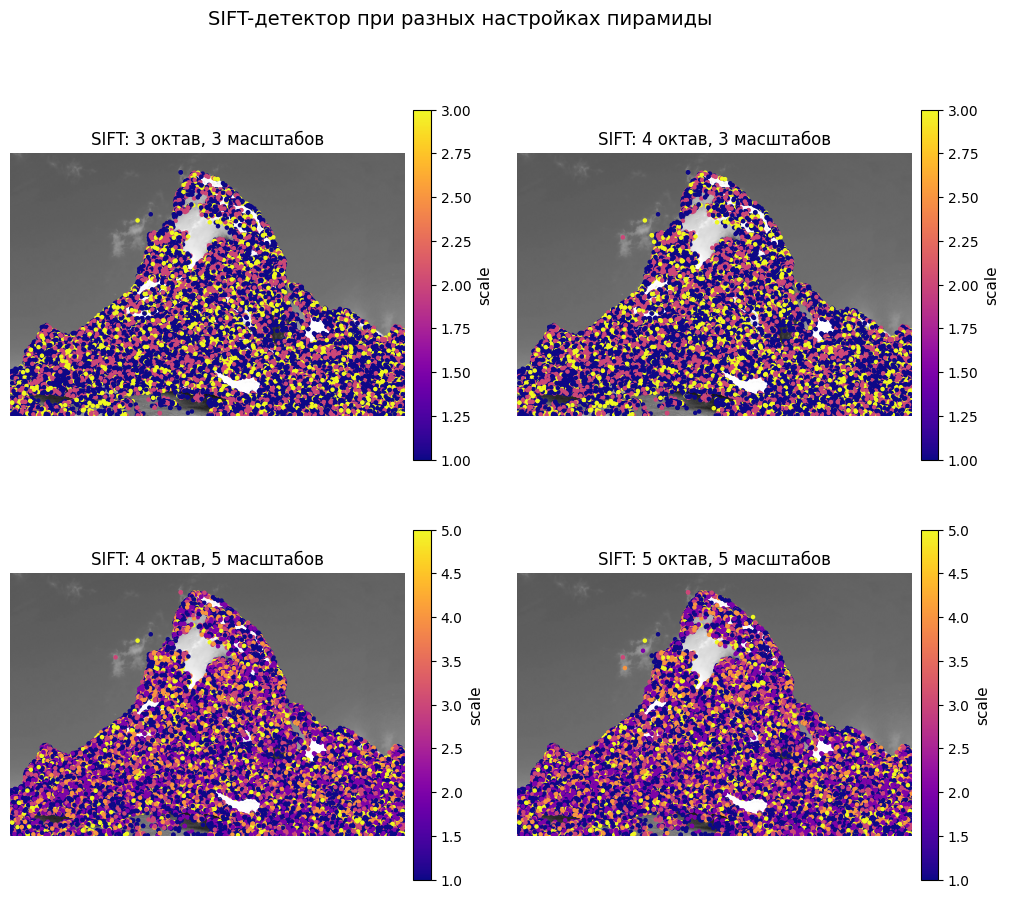

In [9]:
display(Markdown("### 4. SIFT-детектор"))
sift_df, sift_fig = sift_section(gray)
display(sift_df)
show_fig(sift_fig)


### 5. Исследование инвариантности

detector,harris,log,moravec,sift
transform,,,,
downscale2,395,626,595,5956
gamma07,585,2022,1499,22121
original,696,2013,1245,23507
rot30,603,1856,1298,23113


**Моравец: ключевые точки под преобразованиями**

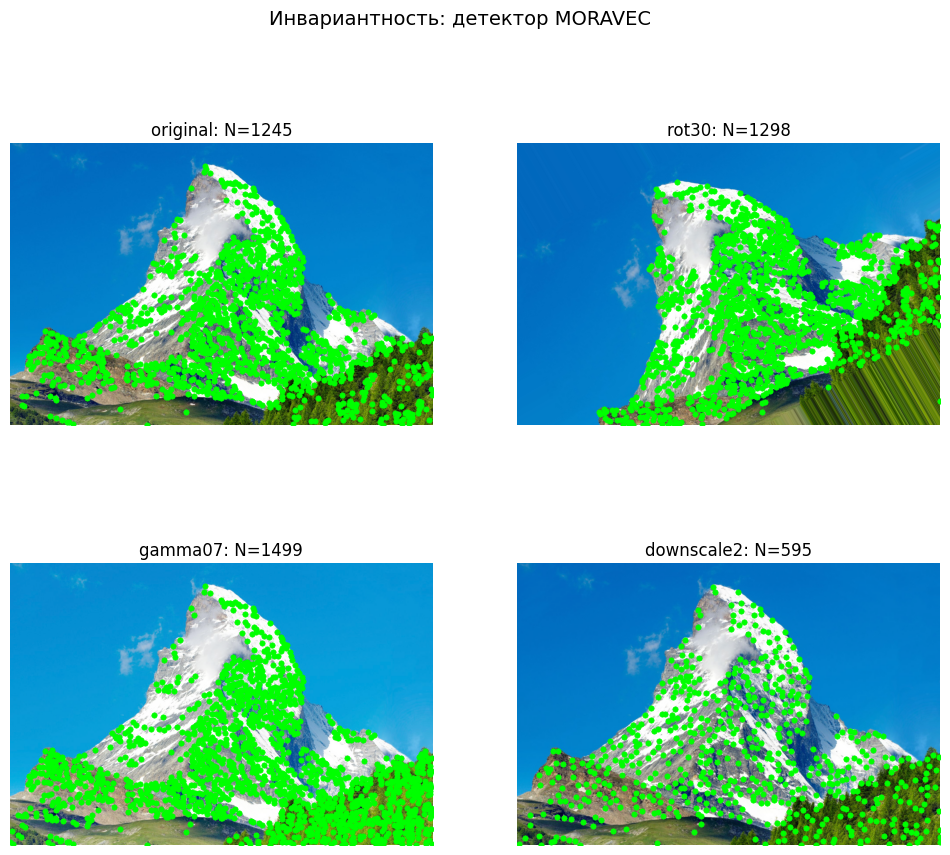

**Харрис: ключевые точки под преобразованиями**

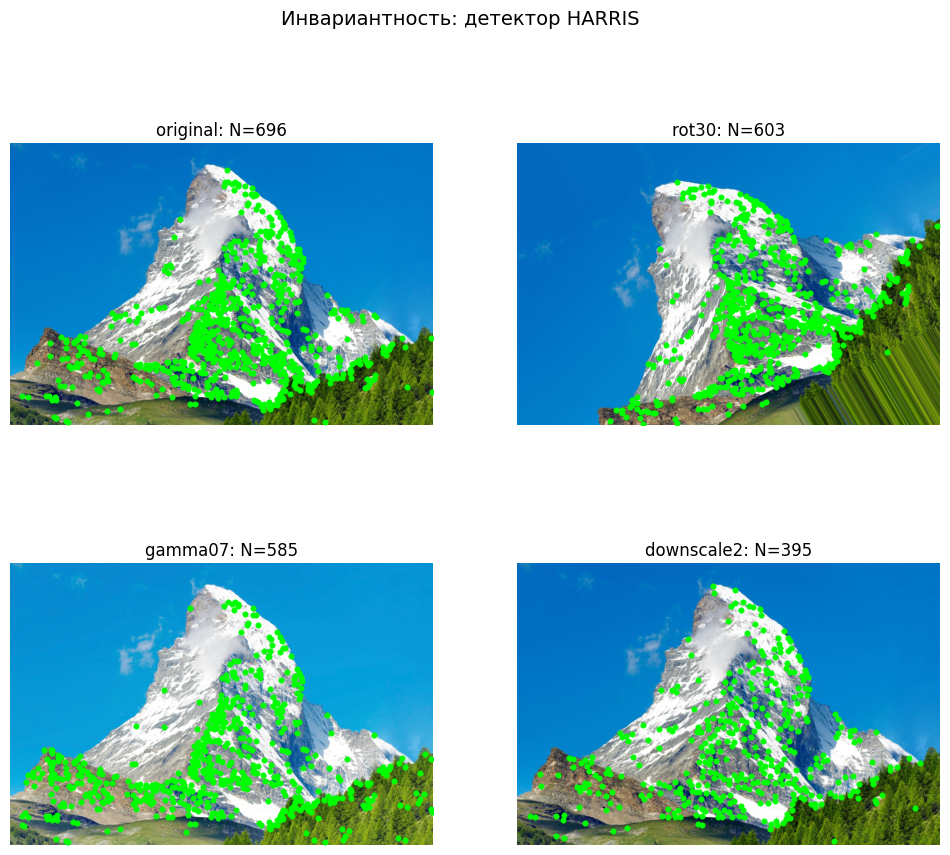

**LoG: ключевые точки под преобразованиями**

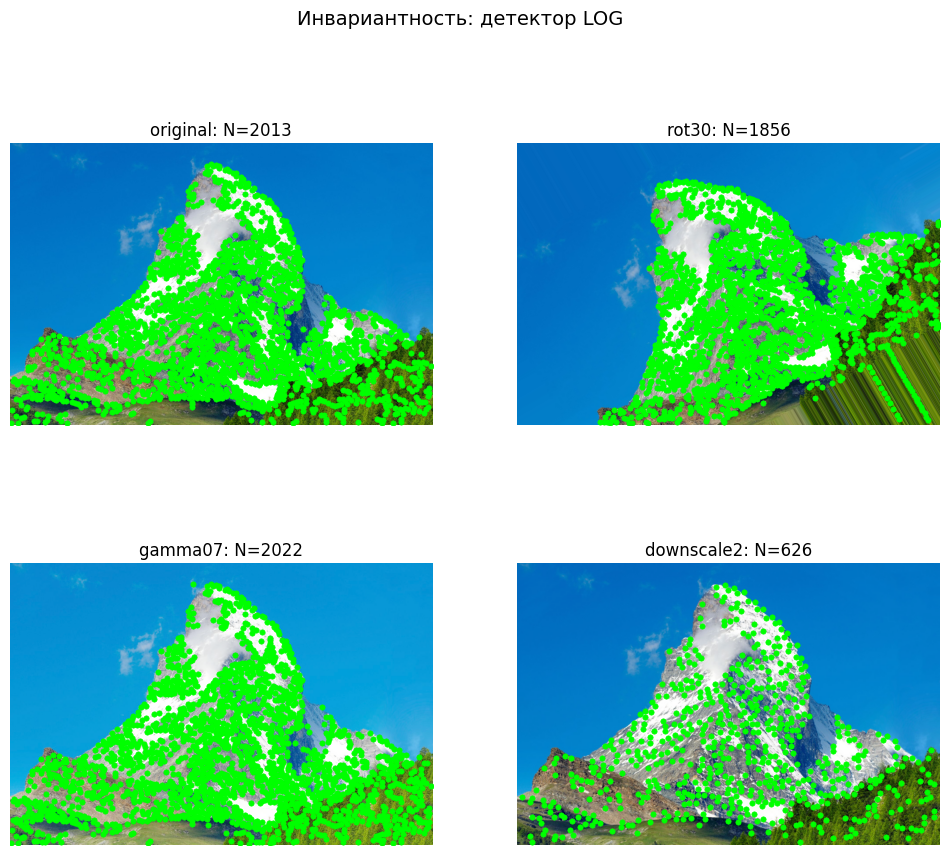

**SIFT: ключевые точки под преобразованиями**

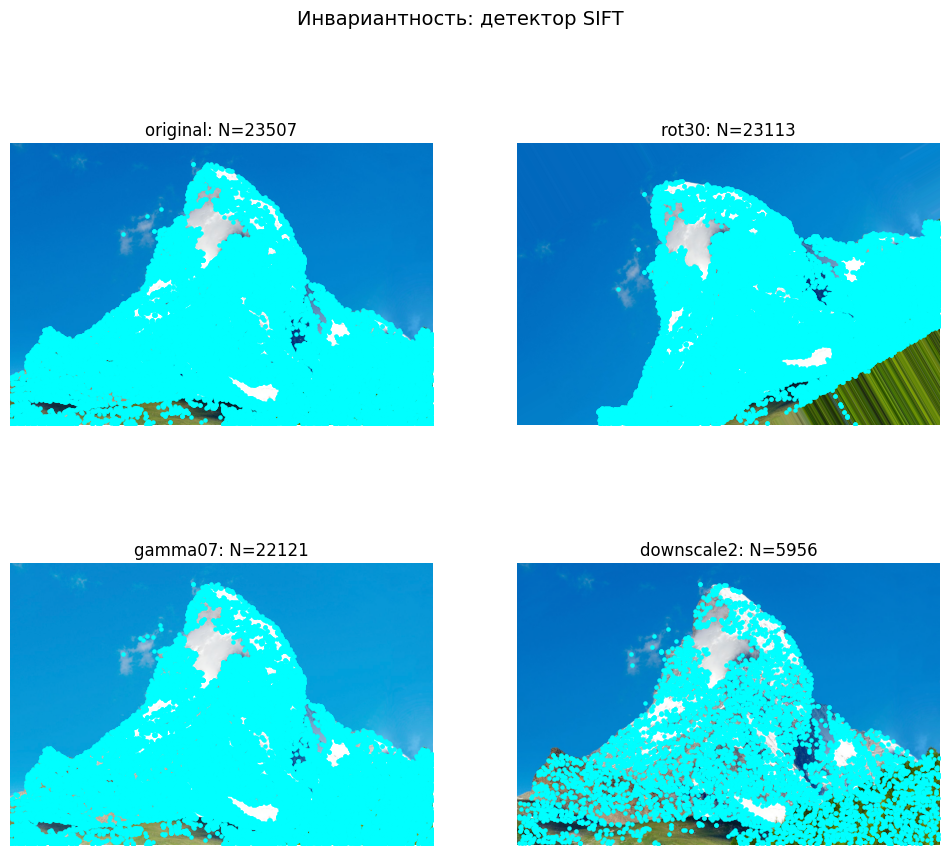

In [11]:
display(Markdown("### 5. Исследование инвариантности"))
log_cfg = {"sigma": 5.0, "threshold_rel": 0.25, "min_distance": 6}

# Исправляем moravec_cfg: ensure all integer parameters are integers (not floats)
moravec_cfg = moravec_df.iloc[1].to_dict()  # окно 9×9
if "window" in moravec_cfg:
    moravec_cfg["window"] = int(moravec_cfg["window"])
if "min_distance" in moravec_cfg:
    moravec_cfg["min_distance"] = int(moravec_cfg["min_distance"])
if "threshold_rel" in moravec_cfg:
    moravec_cfg["threshold_rel"] = float(moravec_cfg["threshold_rel"])

harris_cfg = {
    "block_size": 5,
    "ksize": 3,
    "k": 0.05,
    "threshold_rel": 0.10,
    "min_distance": 6,
}
sift_cfg = {"octaves": 4, "scales": 3}

invariance_df, invariance_figs = invariance_section(image, moravec_cfg, harris_cfg, log_cfg, sift_cfg)
display(invariance_df.pivot(index="transform", columns="detector", values="num_keypoints"))
show_fig(invariance_figs["moravec"], caption="Моравец: ключевые точки под преобразованиями")
show_fig(invariance_figs["harris"], caption="Харрис: ключевые точки под преобразованиями")
show_fig(invariance_figs["log"], caption="LoG: ключевые точки под преобразованиями")
show_fig(invariance_figs["sift"], caption="SIFT: ключевые точки под преобразованиями")


## Мои выводы

- Увеличение окна Моравеца снижает число точек (1601 → 1044) и делает их устойчивее.
- Детектор Харриса даёт компактный набор углов (696), тогда как Нобле/Ши–Томаси покрывают изображение плотнее (>3000 точек).
- LoG-пирамиды показывают, что крупные объекты соответствуют σ≈7–10, мелкие текстуры — σ≈1–2; ключевые точки дополнительно визуализированы окружностями радиуса √2·σ.
- В SIFT количество точек резко возрастает при добавлении масштабов внутри октавы; увеличение числа октав почти не влияет без добавления масштабов.
- По инвариантности: SIFT лучше всего переносит поворот и изменения яркости, LoG стабилен к яркости, но теряет точки при масштабировании, а классические детекторы (Моравец/Харрис) чувствительны к уменьшению и частично к повороту.
